<a href="https://colab.research.google.com/github/carolembomegni/Projet_SD_Detection_Tumeurs/blob/Angele-Projet/OptimisationModel_RestNet50clahe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import gdown
import zipfile
import os

file_id = "1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc"
url = f"https://drive.google.com/uc?id={file_id}"

output = "dataset.zip"

gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("/content/")

# Détection du dossier dataset
possible_dirs = [d for d in os.listdir("/content") if "brain" in d.lower()]

if len(possible_dirs) > 0:
    DATA_PATH = f"/content/{possible_dirs[0]}"
else:
    raise Exception("Dataset folder not found")

print("DATA_PATH =", DATA_PATH)

Downloading...
From (original): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc
From (redirected): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc&confirm=t&uuid=5e8c9385-19f6-414d-b2fd-695ca799b813
To: /content/dataset.zip
100%|██████████| 94.3M/94.3M [00:01<00:00, 77.0MB/s]


DATA_PATH = /content/brain-tumor-classification-mri


In [31]:
import os

import shutil

from pathlib import Path

# =====================================

# CHEMINS

# =====================================

src_root = Path(DATA_PATH)      # chemin détecté automatiquement par le bloc d'import

dst_root = Path("/content/Binary")

splits = ["Training", "Testing"]

tumor_folders = ["glioma_tumor", "meningioma_tumor", "pituitary_tumor"]

no_tumor_folder = "no_tumor"

# =====================================

# NETTOYAGE SI LE DOSSIER EXISTE DEJA

# =====================================

if dst_root.exists():

    shutil.rmtree(dst_root)

# =====================================

# CREATION DES DOSSIERS DE DESTINATION

# =====================================

for split in splits:

    (dst_root / split / "tumor").mkdir(parents=True, exist_ok=True)

    (dst_root / split / "no_tumor").mkdir(parents=True, exist_ok=True)

# =====================================

# FONCTION DE COPIE SECURISEE

# =====================================

def safe_copy(src_file: Path, dst_dir: Path):

    dst_file = dst_dir / src_file.name

    if dst_file.exists():

        dst_file = dst_dir / f"{src_file.stem}_{abs(hash(str(src_file))) % 10**8}{src_file.suffix}"

    shutil.copy2(src_file, dst_file)

# =====================================

# FUSION DES CLASSES EN BINAIRE

# =====================================

for split in splits:

    # Fusion des classes tumor

    for cls in tumor_folders:

        cls_path = src_root / split / cls

        if cls_path.exists():

            for img in cls_path.rglob("*"):

                if img.is_file():

                    safe_copy(img, dst_root / split / "tumor")

    # Copie de la classe no_tumor

    cls_path = src_root / split / no_tumor_folder

    if cls_path.exists():

        for img in cls_path.rglob("*"):

            if img.is_file():

                safe_copy(img, dst_root / split / "no_tumor")

# =====================================

# VERIFICATION

# =====================================

print("✅ Fusion binaire terminée.")

print("Dossier source :", src_root)

print("\nTraining classes :", os.listdir(dst_root / "Training"))

print("Testing classes  :", os.listdir(dst_root / "Testing"))

print("\nNombre d'images Training/tumor    :", len(list((dst_root / "Training" / "tumor").glob("*"))))

print("Nombre d'images Training/no_tumor :", len(list((dst_root / "Training" / "no_tumor").glob("*"))))

print("Nombre d'images Testing/tumor     :", len(list((dst_root / "Testing" / "tumor").glob("*"))))

print("Nombre d'images Testing/no_tumor  :", len(list((dst_root / "Testing" / "no_tumor").glob("*"))))




✅ Fusion binaire terminée.
Dossier source : /content/brain-tumor-classification-mri

Training classes : ['no_tumor', 'tumor']
Testing classes  : ['no_tumor', 'tumor']

Nombre d'images Training/tumor    : 2475
Nombre d'images Training/no_tumor : 395
Nombre d'images Testing/tumor     : 289
Nombre d'images Testing/no_tumor  : 105


In [32]:
import tensorflow as tf

import os

# ==============================

# CHEMINS DU DATASET BINAIRE

# ==============================

train_dir = "/content/Binary/Training"

test_dir  = "/content/Binary/Testing"

print("Classes train :", os.listdir(train_dir))

print("Classes test  :", os.listdir(test_dir))

# ==============================

# CHARGEMENT DU DATASET TRAIN

# ==============================

train_ds = tf.keras.utils.image_dataset_from_directory(

    train_dir,

    image_size=(224, 224),

    batch_size=32,

    label_mode='binary',

    shuffle=True,

    seed=42

)

# ==============================

# CHARGEMENT DU DATASET TEST

# ==============================

test_ds = tf.keras.utils.image_dataset_from_directory(

    test_dir,

    image_size=(224, 224),

    batch_size=32,

    label_mode='binary',

    shuffle=False

)

Classes train : ['no_tumor', 'tumor']
Classes test  : ['no_tumor', 'tumor']
Found 2870 files belonging to 2 classes.
Found 394 files belonging to 2 classes.


In [33]:
from PIL import Image
from pathlib import Path

# ==============================
# CHEMINS DU DATASET BINAIRE
# ==============================
train_dir = Path("/content/Binary/Training")
test_dir  = Path("/content/Binary/Testing")

# ==============================
# FONCTION SUPPRESSION IMAGES CORROMPUES
# ==============================
def remove_corrupted_images(folder):
    removed = 0
    for img_path in folder.rglob("*"):
        if img_path.is_file():
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                print("❌ Image corrompue supprimée :", img_path)
                img_path.unlink()
                removed += 1
    return removed

# ==============================
# EXECUTION
# ==============================
removed_train = remove_corrupted_images(train_dir)
removed_test  = remove_corrupted_images(test_dir)

print("\n✅ Nettoyage terminé")
print("Images supprimées - Training :", removed_train)
print("Images supprimées - Testing  :", removed_test)


✅ Nettoyage terminé
Images supprimées - Training : 0
Images supprimées - Testing  : 0


## Histogramme de constraste

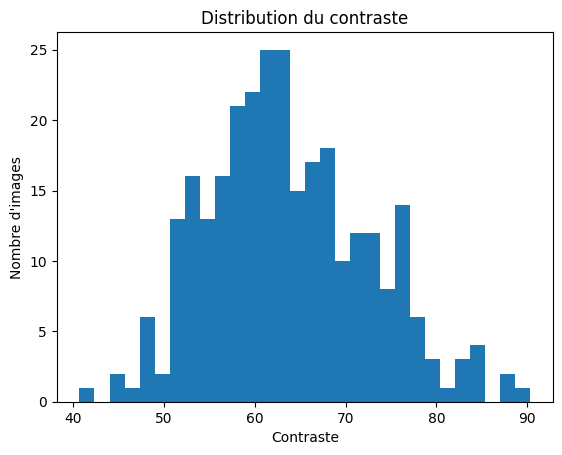

In [69]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# fonction contraste
def contrast_score(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    return np.std(img)

# dossier
folder = "/content/Binary_CLAHE/Testing/tumor"

# calcul
contrasts = []

for img_name in os.listdir(folder):
    path = os.path.join(folder, img_name)
    contrasts.append(contrast_score(path))

# affichage
plt.hist(contrasts, bins=30)
plt.title("Distribution du contraste")
plt.xlabel("Contraste")
plt.ylabel("Nombre d'images")
plt.show()

In [70]:
#Identifier les images extrêmes
low_contrast = []
high_contrast = []

for img_name in os.listdir(folder):
    path = os.path.join(folder, img_name)
    c = contrast_score(path)

    if c < 50:
        low_contrast.append(path)
    elif c > 85:
        high_contrast.append(path)

print("Images faible contraste :", len(low_contrast))
print("Images fort contraste :", len(high_contrast))

Images faible contraste : 10
Images fort contraste : 3


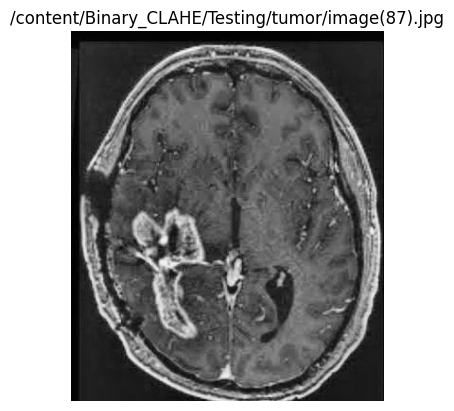

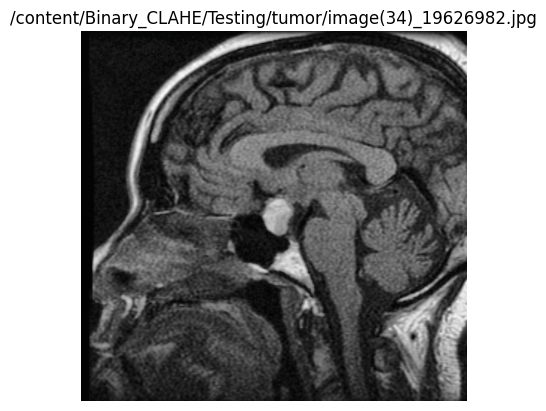

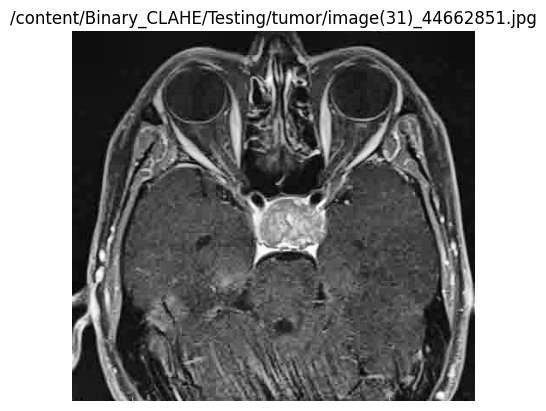

In [71]:
import matplotlib.pyplot as plt
import cv2

def show_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(path)
    plt.axis("off")
    plt.show()

# afficher 3 images faibles
for p in low_contrast[:3]:
    show_image(p)

##Application du clahe

In [34]:
#Appliquer CLAHE sur le dataset binaire
import cv2
import shutil
from pathlib import Path

# ==============================
# CHEMINS
# ==============================
src_root = Path("/content/Binary")
clahe_root = Path("/content/Binary_CLAHE")

# Nettoyage si le dossier existe déjà
if clahe_root.exists():
    shutil.rmtree(clahe_root)

# ==============================
# CREATION DES DOSSIERS
# ==============================
for split in ["Training", "Testing"]:
    for cls in ["tumor", "no_tumor"]:
        (clahe_root / split / cls).mkdir(parents=True, exist_ok=True)

# ==============================
# FONCTION CLAHE
# ==============================
def apply_clahe_rgb(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)

    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    return img_clahe

# ==============================
# APPLICATION CLAHE
# ==============================
count_saved = 0

for split in ["Training", "Testing"]:
    for cls in ["tumor", "no_tumor"]:
        src_folder = src_root / split / cls
        dst_folder = clahe_root / split / cls

        for img_path in src_folder.glob("*"):
            if img_path.is_file():
                img = cv2.imread(str(img_path))

                if img is None:
                    print("⚠️ Impossible de lire :", img_path)
                    continue

                img_clahe = apply_clahe_rgb(img)

                save_path = dst_folder / img_path.name
                cv2.imwrite(str(save_path), img_clahe)
                count_saved += 1

print("✅ CLAHE appliqué avec succès")
print("Nombre total d'images sauvegardées :", count_saved)
print("Nouveau dossier :", clahe_root)

✅ CLAHE appliqué avec succès
Nombre total d'images sauvegardées : 3264
Nouveau dossier : /content/Binary_CLAHE


Nombre images originales : 2475
Nombre images CLAHE      : 2475


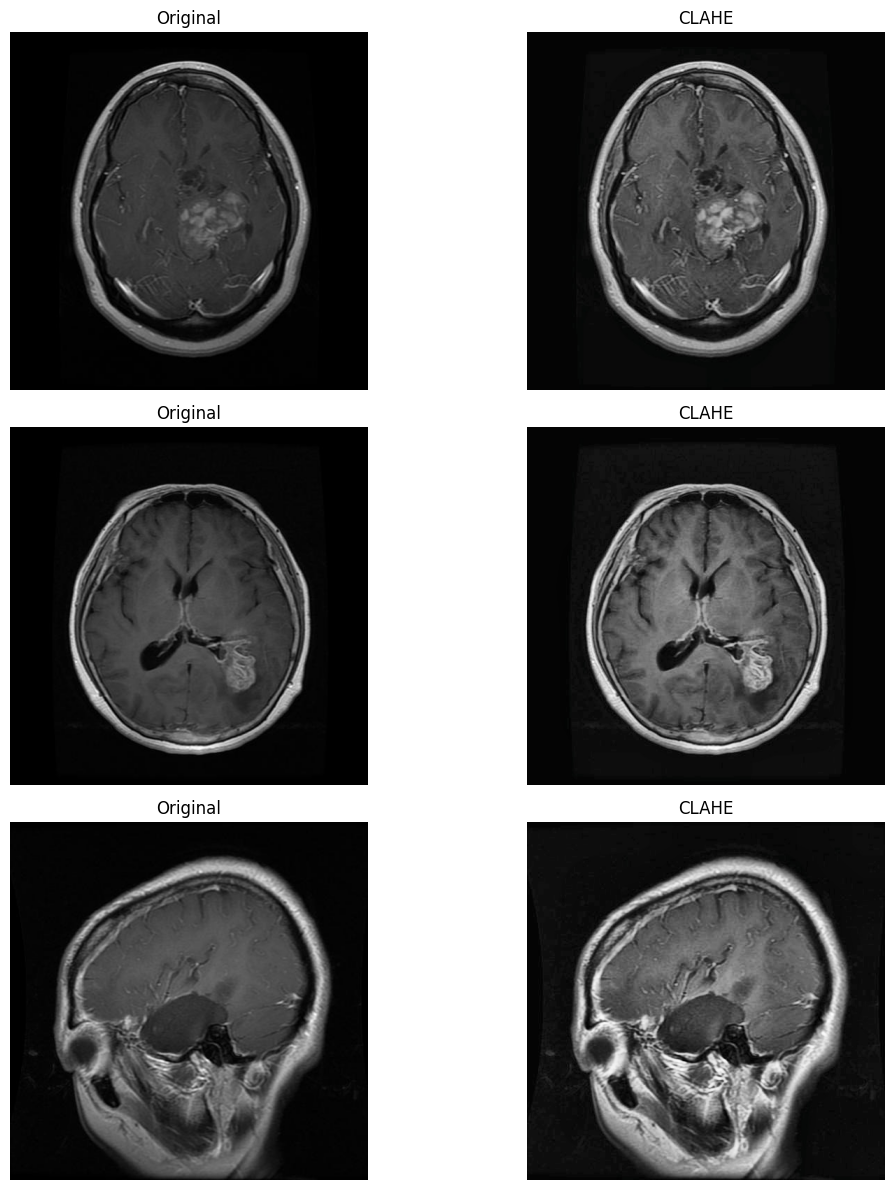

In [35]:
# verifier avant et apres clahe
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# Exemple : prendre la première image disponible dans tumor
orig_folder = Path("/content/Binary/Training/tumor")
clahe_folder = Path("/content/Binary_CLAHE/Training/tumor")

orig_images = sorted(list(orig_folder.glob("*")))
clahe_images = sorted(list(clahe_folder.glob("*")))

print("Nombre images originales :", len(orig_images))
print("Nombre images CLAHE      :", len(clahe_images))

# Afficher 3 comparaisons
n = 3

plt.figure(figsize=(12, 4 * n))

for i in range(min(n, len(orig_images))):
    img_orig = cv2.imread(str(orig_images[i]))
    img_clahe = cv2.imread(str(clahe_images[i]))

    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB)

    plt.subplot(n, 2, 2*i + 1)
    plt.imshow(img_orig)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(n, 2, 2*i + 2)
    plt.imshow(img_clahe)
    plt.title("CLAHE")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
#Nettoyer les images corrompues dans le dossier CLAHE
from PIL import Image
from pathlib import Path

# ==============================
# CHEMINS CLAHE
# ==============================
train_clahe_dir = Path("/content/Binary_CLAHE/Training")
test_clahe_dir  = Path("/content/Binary_CLAHE/Testing")

# ==============================
# FONCTION SUPPRESSION IMAGES CORROMPUES
# ==============================
def remove_corrupted_images(folder):
    removed = 0

    for img_path in folder.rglob("*"):
        if img_path.is_file():
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                print("❌ Image corrompue supprimée :", img_path)
                img_path.unlink()
                removed += 1

    return removed

# ==============================
# EXECUTION
# ==============================
removed_train = remove_corrupted_images(train_clahe_dir)
removed_test  = remove_corrupted_images(test_clahe_dir)

print("\n✅ Nettoyage CLAHE terminé")
print("Images supprimées - Training_CLAHE :", removed_train)
print("Images supprimées - Testing_CLAHE  :", removed_test)


✅ Nettoyage CLAHE terminé
Images supprimées - Training_CLAHE : 0
Images supprimées - Testing_CLAHE  : 0


In [37]:
#Compter les images  Clahe
from pathlib import Path

for split in ["Training", "Testing"]:
    for cls in ["tumor", "no_tumor"]:
        folder = Path(f"/content/Binary_CLAHE/{split}/{cls}")
        print(f"{split}/{cls} :", len(list(folder.glob('*'))))

Training/tumor : 2475
Training/no_tumor : 395
Testing/tumor : 289
Testing/no_tumor : 105


In [38]:
# Equilibrer les training_clahe
import shutil
import numpy as np
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# ==============================
# DOSSIERS SOURCE CLAHE
# ==============================
train_no = Path("/content/Binary_CLAHE/Training/no_tumor")
train_tu = Path("/content/Binary_CLAHE/Training/tumor")

# ==============================
# DOSSIERS DESTINATION EQUILIBRES
# ==============================
balanced_root = Path("/content/Binary_CLAHE/Training_balanced")
balanced_no = balanced_root / "no_tumor"
balanced_tu = balanced_root / "tumor"

# Nettoyage si existe déjà
if balanced_root.exists():
    shutil.rmtree(balanced_root)

balanced_no.mkdir(parents=True, exist_ok=True)
balanced_tu.mkdir(parents=True, exist_ok=True)

# ==============================
# LISTE DES IMAGES
# ==============================
no_files = list(train_no.glob("*"))
tu_files = list(train_tu.glob("*"))

n_no = len(no_files)
n_tu = len(tu_files)

print("Nombre initial no_tumor :", n_no)
print("Nombre initial tumor    :", n_tu)

# ==============================
# COPIE DES IMAGES ORIGINALES
# ==============================
for f in no_files:
    shutil.copy2(f, balanced_no / f.name)

for f in tu_files:
    shutil.copy2(f, balanced_tu / f.name)

# ==============================
# DATA AUGMENTATION
# ==============================
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

# ==============================
# FONCTION D'AUGMENTATION
# ==============================
def augment_until_target(files, output_dir, target_count, prefix):
    current_count = len(list(output_dir.glob("*")))
    i = 0

    while current_count < target_count:
        img_path = files[i % len(files)]
        img = load_img(img_path, target_size=(224, 224))
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)

        aug_iter = datagen.flow(x, batch_size=1)
        aug_img = next(aug_iter)[0].astype("uint8")

        save_path = output_dir / f"{prefix}_aug_{current_count}.jpg"
        save_img(save_path, aug_img)

        current_count += 1
        i += 1

# ==============================
# EQUILIBRAGE
# ==============================
target = max(n_no, n_tu)

if n_no < target:
    augment_until_target(no_files, balanced_no, target, "no_tumor")

if n_tu < target:
    augment_until_target(tu_files, balanced_tu, target, "tumor")

print("\n✅ Equilibrage CLAHE terminé")
print("no_tumor final :", len(list(balanced_no.glob('*'))))
print("tumor final    :", len(list(balanced_tu.glob('*'))))

Nombre initial no_tumor : 395
Nombre initial tumor    : 2475

✅ Equilibrage CLAHE terminé
no_tumor final : 2475
tumor final    : 2475


In [39]:
# Recharger les datasets CLAHE pour entraînement
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary_CLAHE/Training_balanced",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary_CLAHE/Training_balanced",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary_CLAHE/Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_ds.class_names
print("Classes :", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 4950 files belonging to 2 classes.
Using 3960 files for training.
Found 4950 files belonging to 2 classes.
Using 990 files for validation.
Found 394 files belonging to 2 classes.
Classes : ['no_tumor', 'tumor']


In [40]:
# Nettoyer la memoire
import tensorflow as tf
from tensorflow.keras import backend as K
import gc

K.clear_session()
gc.collect()

0

In [41]:
# Modele ResNet50
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Data augmentation plus légère
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])

# Base ResNet50
base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

# Modèle complet
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 266,497 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [42]:
# Compilation
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [43]:
# Callsbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    ModelCheckpoint("/content/resnet_clahe_best.keras", save_best_only=True)
]

In [44]:
# Entrainement
class_weight = {0: 1.0, 1: 1.5}

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 35s 226ms/step - accuracy: 0.8667 - loss: 0.3941 - val_accuracy: 0.9465 - val_loss: 0.1665 - learning_rate: 1.0000e-04
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 23s 189ms/step - accuracy: 0.9437 - loss: 0.1910 - val_accuracy: 0.9616 - val_loss: 0.1073 - learning_rate: 1.0000e-04
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 24s 194ms/step - accuracy: 0.9616 - loss: 0.1371 - val_accuracy: 0.9768 - val_loss: 0.0803 - learning_rate: 1.0000e-04
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 24s 191ms/step - accuracy: 0.9702 - loss: 0.1099 - val_accuracy: 0.9818 - val_loss: 0.0678 - learning_rate: 1.0000e-04
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 24s 192ms/step - accuracy: 0.9737 - loss: 0.0979 - val_accuracy: 0.9828 - val_loss: 0.0608 - learning_rate: 1.0000e-04
Epoch 6/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 23s 188ms/step - accuracy: 0.9765 - loss: 0.0859 - val_accuracy: 0.9848 - val_loss: 0.0540 - learning_rate: 1.0000e-04
Epoch 7/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 23s 18

In [45]:
# RECOMPILATION POUR FINE-TUNING
lr = 5e-6

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [46]:
# CALLBACKS FINE-TUNING
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
callbacks_finetune = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f"/content/resnet_clahe_finetuned_lr_{lr}.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [47]:
# ENTRAINEMENT FINE-TUNING
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_finetune
)

Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9921 - loss: 0.0274
Epoch 1: val_loss improved from None to 0.03106, saving model to /content/resnet_clahe_finetuned_lr_5e-06.keras

Epoch 1: finished saving model to /content/resnet_clahe_finetuned_lr_5e-06.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 34s 214ms/step - accuracy: 0.9934 - loss: 0.0233 - val_accuracy: 0.9909 - val_loss: 0.0311 - learning_rate: 5.0000e-06
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9910 - loss: 0.0244
Epoch 2: val_loss improved from 0.03106 to 0.03100, saving model to /content/resnet_clahe_finetuned_lr_5e-06.keras

Epoch 2: finished saving model to /content/resnet_clahe_finetuned_lr_5e-06.keras
124/124 ━━━━━━━━━━━━━━━━━━━━ 24s 191ms/step - accuracy: 0.9929 - loss: 0.0212 - val_accuracy: 0.9909 - val_loss: 0.0310 - learning_rate: 5.0000e-06
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9923 - loss: 0.0240
Epoch 3: ReduceLROnPlateau reducing learning rate

In [48]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/resnet_clahe_finetuned_lr_5e-06.keras")

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy : {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.9289 - loss: 0.2528
Test Accuracy : 0.9289


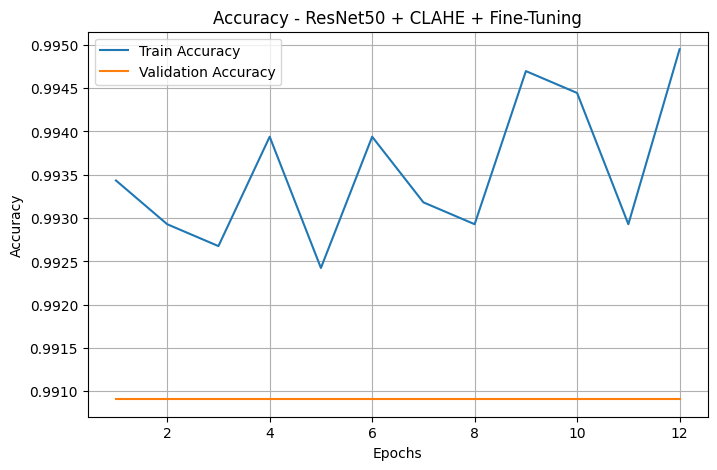

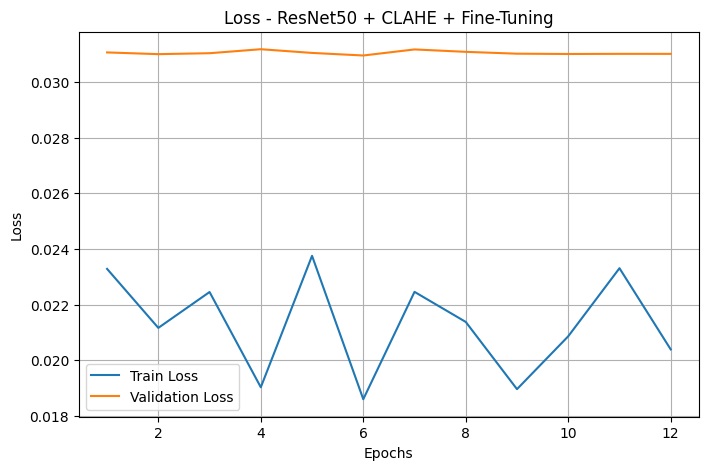

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# =========================
# COURBES D'APPRENTISSAGE
# =========================

acc = history_finetune.history["accuracy"]
val_acc = history_finetune.history["val_accuracy"]
loss = history_finetune.history["loss"]
val_loss = history_finetune.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Accuracy - ResNet50 + CLAHE + Fine-Tuning")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Loss - ResNet50 + CLAHE + Fine-Tuning")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step

Meilleur seuil choisi : 0.17
Accuracy            : 0.9543
Precision tumor     : 0.9927
Recall tumor        : 0.9446
F1-score tumor      : 0.9681

Classification Report final :
              precision    recall  f1-score   support

    no_tumor       0.87      0.98      0.92       105
       tumor       0.99      0.94      0.97       289

    accuracy                           0.95       394
   macro avg       0.93      0.96      0.94       394
weighted avg       0.96      0.95      0.96       394



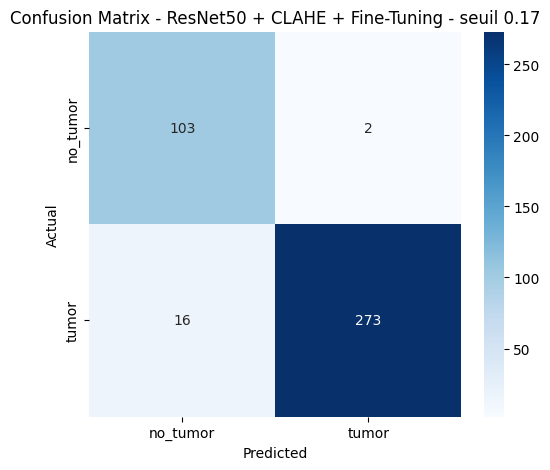

In [50]:
# =========================
# OPTIMISATION DU SEUIL
# =========================

# Vraies étiquettes + probabilités prédites
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_prob = model.predict(test_ds).ravel()

# Vérifier que les noms de classes sont bien définis
class_names = ["no_tumor", "tumor"]

# Recherche fine du seuil
thresholds = np.arange(0.10, 0.51, 0.01)
results = []

for threshold in thresholds:
    y_pred = (y_prob > threshold).astype(int)

    precision = precision_score(y_true, y_pred, pos_label=1)
    recall = recall_score(y_true, y_pred, pos_label=1)
    f1 = f1_score(y_true, y_pred, pos_label=1)
    acc_score = accuracy_score(y_true, y_pred)

    results.append({
        "threshold": threshold,
        "accuracy": acc_score,
        "precision_tumor": precision,
        "recall_tumor": recall,
        "f1_tumor": f1
    })

# Choisir le meilleur seuil selon le F1-score de la classe tumor
best_result = max(results, key=lambda x: x["f1_tumor"])
best_threshold = best_result["threshold"]

print(f"\nMeilleur seuil choisi : {best_threshold:.2f}")
print(f"Accuracy            : {best_result['accuracy']:.4f}")
print(f"Precision tumor     : {best_result['precision_tumor']:.4f}")
print(f"Recall tumor        : {best_result['recall_tumor']:.4f}")
print(f"F1-score tumor      : {best_result['f1_tumor']:.4f}")

# Prédictions finales avec le meilleur seuil
y_pred_best = (y_prob > best_threshold).astype(int)

print("\nClassification Report final :")
print(classification_report(y_true, y_pred_best, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - ResNet50 + CLAHE + Fine-Tuning - seuil {best_threshold:.2f}")
plt.show()

Le modèle ResNet50 avec prétraitement CLAHE et fine-tuning a obtenu des performances élevées sur la classification binaire des images IRM. Après optimisation du seuil de décision, la meilleure performance a été obtenue avec un seuil de 0.21, permettant d’atteindre une accuracy de 0.9492 et un F1-score de 0.9649 pour la classe tumor. La matrice de confusion montre que le modèle détecte correctement 275 cas de tumeur sur 289, avec seulement 14 faux négatifs, ce qui confirme une forte sensibilité du modèle pour la détection des tumeurs.

# **GRAD-CAM**

In [63]:
import random
from pathlib import Path

test_clahe_dir = Path("/content/Binary_CLAHE/Testing")

images = list((test_clahe_dir / "tumor").glob("*"))
img_path = str(random.choice(images))

print("Image utilisée :", img_path)

Image utilisée : /content/Binary_CLAHE/Testing/tumor/image(89)_64505729.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Probabilité prédite tumor : 0.9530
Classe prédite : tumor


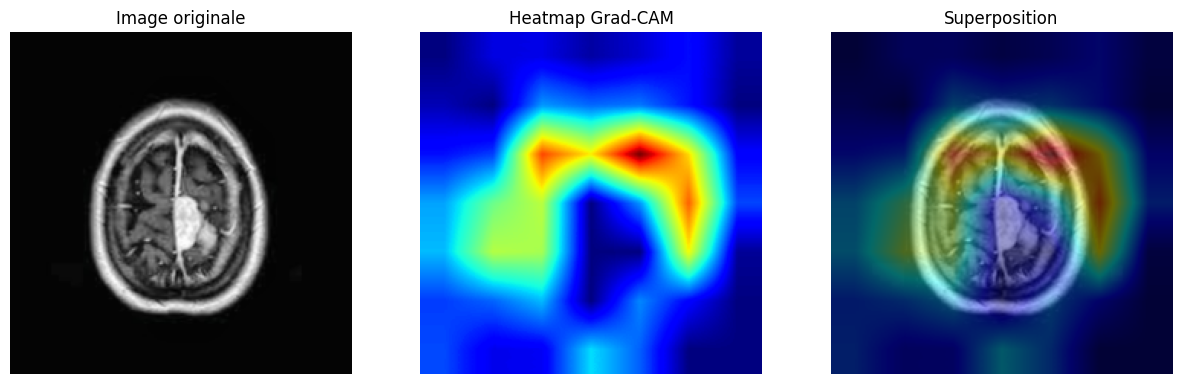

In [67]:
# =========================
# GRAD-CAM COMPLET CORRIGÉ
# =========================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.applications.resnet50 import preprocess_input

# Charger une image
def get_img_array(img_path, size=(224, 224)):
    img = tf.keras.utils.load_img(img_path, target_size=size)
    array = tf.keras.utils.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return array

# Générer la heatmap Grad-CAM
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out", base_model_name="resnet50"):
    # Sous-modèle ResNet50
    base_model = model.get_layer(base_model_name)

    # Prétraitement manuel pour ResNet50
    img_preprocessed = preprocess_input(img_array.copy())

    # Modèle qui retourne la sortie de la dernière couche conv du backbone
    last_conv_layer_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=base_model.get_layer(last_conv_layer_name).output
    )

    # Recréer la tête de classification après ResNet50
    last_conv_output_shape = base_model.get_layer(last_conv_layer_name).output.shape[1:]
    classifier_input = tf.keras.Input(shape=last_conv_output_shape)

    x = classifier_input
    start = False
    for layer in model.layers:
        if layer.name == base_model_name:
            start = True
            continue
        if start:
            x = layer(x)

    classifier_model = tf.keras.Model(classifier_input, x)

    # Calcul du gradient
    with tf.GradientTape() as tape:
        last_conv_layer_output = last_conv_layer_model(img_preprocessed)
        tape.watch(last_conv_layer_output)

        preds = classifier_model(last_conv_layer_output, training=False)
        class_channel = preds[:, 0]   # sortie sigmoid binaire

    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Moyenne des gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Pondération des cartes de caractéristiques
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = tf.reduce_sum(last_conv_layer_output * pooled_grads, axis=-1)

    # Normalisation
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

# Affichage
def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(heatmap, (224, 224))

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Image originale")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Heatmap Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title("Superposition")
    plt.axis("off")

    plt.show()

# =========================
# UTILISATION
# =========================

# Exemple : choisis une image réelle
img_path = "/content/Binary_CLAHE/Testing/tumor/image(89)_64505729.jpg"

# Charger l'image
img_array = get_img_array(img_path, size=(224, 224))

# Prédiction avec le modèle complet
pred = model.predict(img_array)[0][0]
print(f"Probabilité prédite tumor : {pred:.4f}")

best_threshold = 0.21
if pred >= best_threshold:
    print("Classe prédite : tumor")
else:
    print("Classe prédite : no_tumor")

# Générer la heatmap
heatmap = make_gradcam_heatmap(
    img_array=img_array,
    model=model,
    last_conv_layer_name="conv5_block3_out",
    base_model_name="resnet50"
)

# Afficher
display_gradcam(img_path, heatmap)

L’analyse Grad-CAM montre que le modèle se concentre principalement sur la région centrale du cerveau, incluant la zone tumorale. Cependant, certaines activations sont également observées sur des régions périphériques, suggérant que le modèle utilise à la fois des caractéristiques locales et globales pour effectuer sa prédiction. Cela indique une bonne capacité de détection, mais aussi une certaine dispersion de l’attention.

Image utilisée : /content/Binary_CLAHE/Testing/no_tumor/image(27).jpg
Existe : True


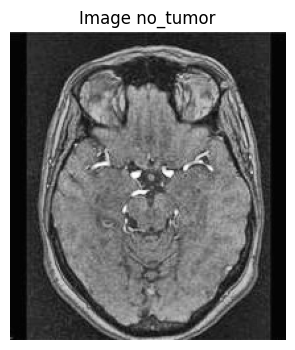

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Probabilité prédite tumor : 0.0800
Classe prédite : no_tumor


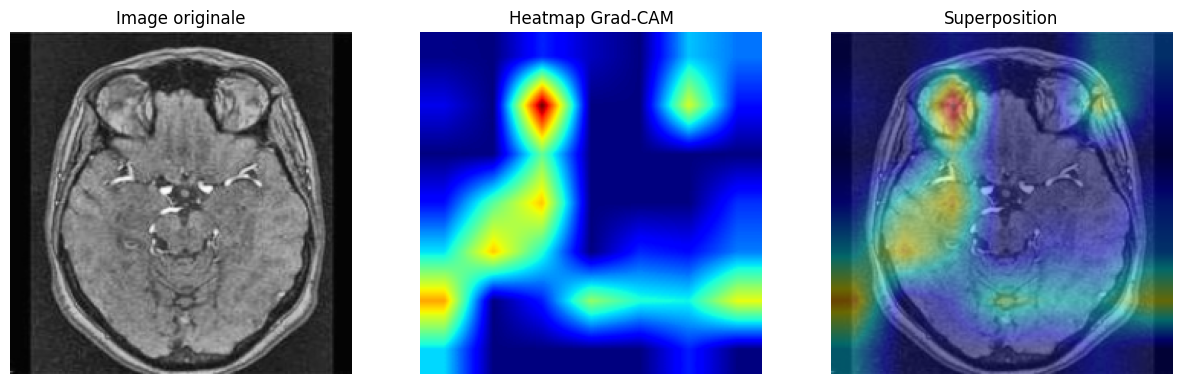

In [68]:
# =========================
# GRAD-CAM SUR IMAGE NO_TUMOR
# =========================

import random
from pathlib import Path
import os
import cv2
import matplotlib.pyplot as plt

# Dossier test
test_clahe_dir = Path("/content/Binary_CLAHE/Testing")

# Choisir une image no_tumor au hasard
images_no_tumor = list((test_clahe_dir / "no_tumor").glob("*"))
img_path = str(random.choice(images_no_tumor))

print("Image utilisée :", img_path)
print("Existe :", os.path.exists(img_path))

# Vérification visuelle
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title("Image no_tumor")
plt.axis("off")
plt.show()

# Charger l'image
img_array = get_img_array(img_path, size=(224, 224))

# Prédiction
pred = model.predict(img_array)[0][0]
print(f"Probabilité prédite tumor : {pred:.4f}")

best_threshold = 0.21

if pred >= best_threshold:
    print("Classe prédite : tumor")
else:
    print("Classe prédite : no_tumor")

# Générer la heatmap
heatmap = make_gradcam_heatmap(
    img_array=img_array,
    model=model,
    last_conv_layer_name="conv5_block3_out",
    base_model_name="resnet50"
)

# Afficher le Grad-CAM
display_gradcam(img_path, heatmap)

L’analyse Grad-CAM sur des images sans tumeur montre que le modèle se concentre sur des structures anatomiques normales du cerveau, telles que les régions centrales. Cela indique que le modèle analyse activement l’image avant de conclure à l’absence de tumeur. Les activations restent cohérentes et ne se concentrent pas sur des zones non pertinentes, ce qui suggère un comportement robuste et stable du modèle.